In [7]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
from simulation.core import SimulationParams, SimulationRunner
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import glob

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
params_baseline = SimulationParams(
    enable_logging=True,
    mm_lag=0.01,
    sniper_lag=0.001,
    order_submission_delay=0,
    n_snipers=2,
    mm_max_inventory = 500.0
)

In [9]:
params_scenario2 = SimulationParams(
    enable_logging=True,
    mm_lag=0.001,
    sniper_lag=0.001,
    order_submission_delay=0,
    n_snipers=10,
    mm_max_inventory = 500.0
)

In [10]:
params_scenario3 = SimulationParams(
    enable_logging=True,
    mm_lag=0.01,
    sniper_lag=0.001,
    order_submission_delay=0.011,
    n_snipers=2,
    mm_max_inventory = 500.0
)
runner_scenario3 = SimulationRunner(params_scenario3)

Logging to 20260602_170152_068242


In [11]:
import concurrent.futures
import dataclasses
import multiprocessing as mp
import time

N_PATHS   = 10
N_WORKERS = min(8, os.cpu_count() or 4)
_N_GRID   = 500   # interpolation points per path for band plots

def _run_single(args):
    # all imports must live inside the function — each Jupyter cell has its
    # own module namespace, so outer-cell globals are not visible to workers
    import sys, numpy as np, dataclasses as dc
    sys.path.append('../')
    from simulation.core import SimulationRunner

    params, seed, n_grid = args
    p      = dc.replace(params, seed=seed, enable_logging=False)
    result = SimulationRunner(p).run()
    hist    = result.mm_pnl_history
    mm_snap = hist[-1] if hist else {}

    t_grid     = np.linspace(0, p.T, n_grid)
    times_full = np.array([h['time']      for h in hist])
    pnl_full   = np.array([h['total_pnl'] for h in hist])
    inv_full   = np.array([h['inventory'] for h in hist])

    return {
        'mm_final_pnl':              float(pnl_full[-1]) if len(pnl_full) else float('nan'),
        'mm_final_alpha':            result.mm_final_alpha,
        'mm_final_spread_ticks':     result.mm_final_spread_ticks,
        'mm_spread_income':          mm_snap.get('spread_income', 0.0),
        'mm_adverse_selection_loss': mm_snap.get('adverse_selection_loss', 0.0),
        'mm_total_attributed_pnl':   mm_snap.get('total_attributed_pnl', 0.0),
        'sniper1_pnl':               result.sniper1_pnl,
        'sniper2_pnl':               result.sniper2_pnl,
        'sniper1_trades':            result.sniper1_trades,
        'sniper2_trades':            result.sniper2_trades,
        'investor_trades':           result.investor_trades,
        'avg_spread':                result.avg_spread,
        'total_events':              result.total_events,
        't_grid':                    t_grid,
        'pnl_series':                np.interp(t_grid, times_full, pnl_full),
        'inv_series':                np.interp(t_grid, times_full, inv_full),
    }

def run_monte_carlo(params, n_paths=N_PATHS, n_workers=N_WORKERS):
    ctx  = mp.get_context('fork')
    args = [(params, s, _N_GRID) for s in range(n_paths)]
    with concurrent.futures.ProcessPoolExecutor(max_workers=n_workers, mp_context=ctx) as ex:
        results = list(ex.map(_run_single, args, chunksize=20))
    return results


In [12]:
mc_scenarios = {
    'Scenario 1 - Baseline - 2 Snipers with Speed advantage': params_baseline,
    'Scenario 2 - No Speed Advantage - 10 Snipers': params_scenario2,
    'Scenario 3 - Baseline with Order Submission Delay': params_scenario3,
}

mc_results = {}
for name, params in mc_scenarios.items():
    t0 = time.time()
    print(f"Running {N_PATHS} paths for {name} ...", end=' ', flush=True)
    mc_results[name] = run_monte_carlo(params)
    print(f"done in {time.time() - t0:.1f}s")


Running 10 paths for Scenario 1 - Baseline - 2 Snipers with Speed advantage ... 

done in 80.0s
Running 10 paths for Scenario 2 - No Speed Advantage - 10 Snipers ... done in 156.6s
Running 10 paths for Scenario 3 - Baseline with Order Submission Delay ... done in 99.9s


In [13]:
def _mc_stats(runs, key):
    arr = np.array([r[key] for r in runs])
    return {'mean': arr.mean(), 'std': arr.std(),
            'p5':   np.percentile(arr, 5),
            'p95':  np.percentile(arr, 95)}

metrics = [
    'mm_final_pnl',
    'mm_spread_income',
    'mm_adverse_selection_loss',
    'mm_total_attributed_pnl',
    'mm_final_alpha',
    'mm_final_spread_ticks',
    'avg_spread',
    'investor_trades',
    'sniper1_pnl',
    'sniper1_trades',
]

rows = []
for name, runs in mc_results.items():
    for m in metrics:
        s = _mc_stats(runs, m)
        rows.append({'scenario': name, 'metric': m, **s})

summary = pd.DataFrame(rows).set_index(['scenario', 'metric'])
pd.set_option('display.float_format', '{:.3f}'.format)
summary


mean  \
scenario                                           metric                                
Scenario 1 - Baseline - 2 Snipers with Speed ad... mm_final_pnl                164.212   
                                                   mm_spread_income            918.700   
                                                   mm_adverse_selection_loss  -496.304   
                                                   mm_total_attributed_pnl     422.396   
                                                   mm_final_alpha                0.268   
                                                   mm_final_spread_ticks         6.200   
                                                   avg_spread                    0.090   
                                                   investor_trades           28794.900   
                                                   sniper1_pnl                 244.777   
                                                   sniper1_trades             6044.400   
Scenario 2 - No Speed Advantage - 10 Snipers       mm_final_pnl                264.499   
                                                   mm_spread_income           1085.868   
                                                   mm_adverse_selection_loss  -908.783   
                                                   mm_total_attributed_pnl     177.085   
                                                   mm_final_alpha                0.430   
                                                   mm_final_spread_ticks         7.400   
                                                   avg_spread                    0.105   
                                                   investor_trades           28707.400   
                                                   sniper1_pnl                  91.055   
                                                   sniper1_trades             2232.800   
Scenario 3 - Baseline with Order Submission Delay  mm_final_pnl                351.432   
                                                   mm_spread_income            542.469   
                                                   mm_adverse_selection_loss   -26.664   
                                                   mm_total_attributed_pnl     515.805   
                                                   mm_final_alpha                0.012   
                                                   mm_final_spread_ticks         4.000   
                                                   avg_spread                    0.057   
                                                   investor_trades           27573.900   
                                                   sniper1_pnl                   0.000   
                                                   sniper1_trades                0.000   

                                                                                  std  \
scenario                                           metric                               
Scenario 1 - Baseline - 2 Snipers with Speed ad... mm_final_pnl              1488.392   
                                                   mm_spread_income             4.987   
                                                   mm_adverse_selection_loss    5.512   
                                                   mm_total_attributed_pnl      4.978   
                                                   mm_final_alpha               0.060   
                                                   mm_final_spread_ticks        0.600   
                                                   avg_spread                   0.000   
                                                   investor_trades            196.100   
                                                   sniper1_pnl                  3.289   
                                                   sniper1_trades              45.732   
Scenario 2 - No Speed Advantage - 10 Snipers       mm_final_pnl              2392.130   
                                            

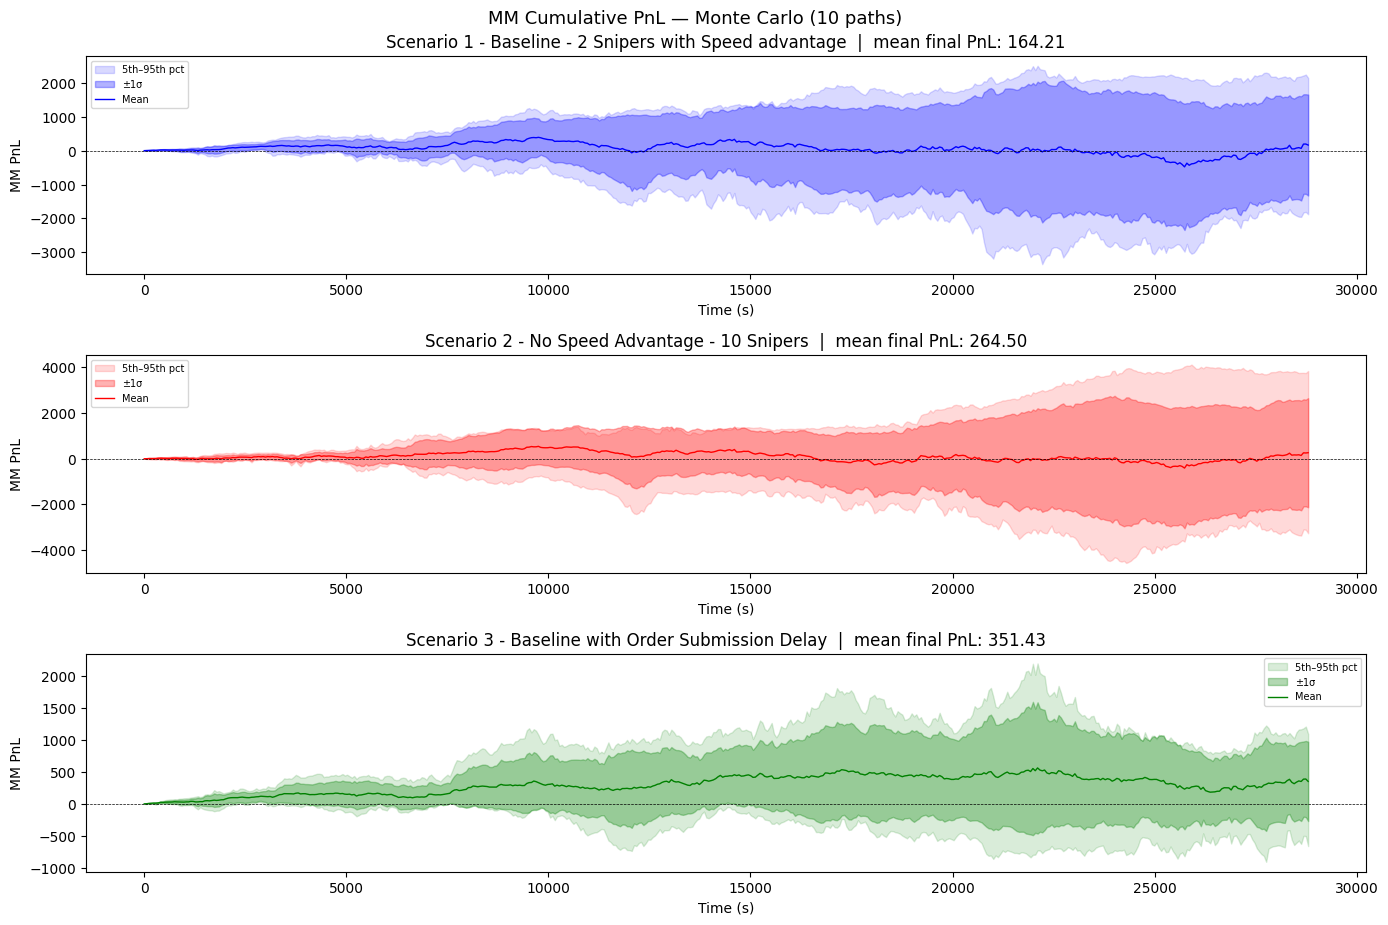

In [16]:
_colors = {
    'Scenario 1 - Baseline - 2 Snipers with Speed advantage':   'blue',
    'Scenario 2 - No Speed Advantage - 10 Snipers': 'red',
    'Scenario 3 - Baseline with Order Submission Delay': 'green',

}

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
axes = axes.flatten()

for i, (name, runs) in enumerate(mc_results.items()):
    ax     = axes[i]
    color  = _colors[name]
    t      = runs[0]['t_grid']
    matrix = np.array([r['pnl_series'] for r in runs])
    mean   = matrix.mean(axis=0)
    std    = matrix.std(axis=0)
    p5     = np.percentile(matrix, 5, axis=0)
    p95    = np.percentile(matrix, 95, axis=0)

    ax.fill_between(t, p5,           p95,           alpha=0.15, color=color, label='5th–95th pct')
    ax.fill_between(t, mean - std,   mean + std,    alpha=0.30, color=color, label='±1σ')
    ax.plot(t, mean, color=color, linewidth=1.0, label='Mean')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(f'{name}  |  mean final PnL: {mean[-1]:.2f}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('MM PnL')
    ax.legend(fontsize=7)
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter(useOffset=False))

axes[-1].set_visible(False)
fig.suptitle(f'MM Cumulative PnL — Monte Carlo ({N_PATHS} paths)', fontsize=13)
plt.tight_layout()
plt.show()


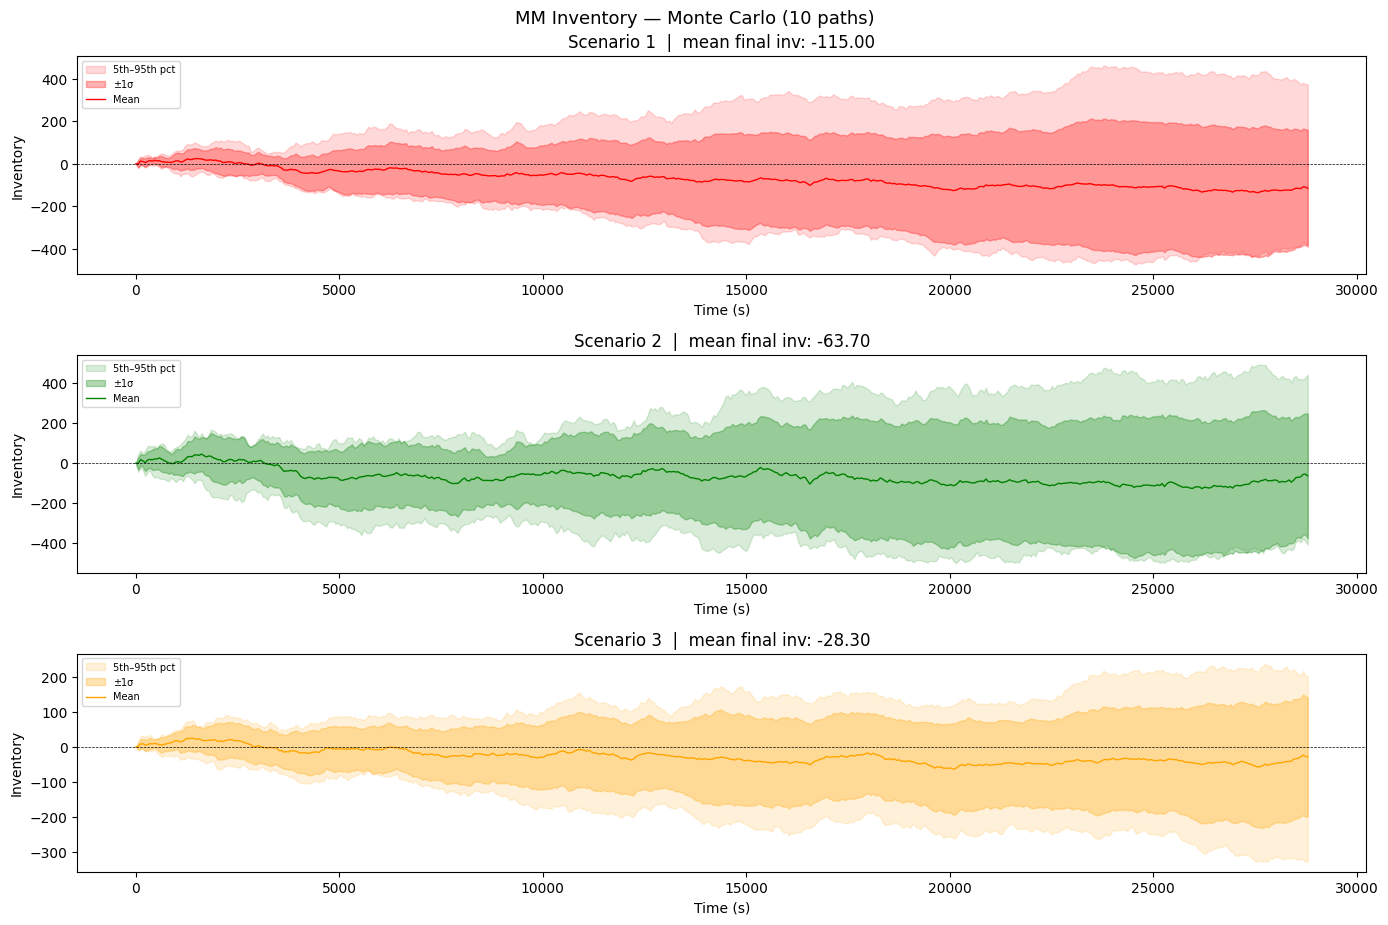

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
axes = axes.flatten()

for i, (name, runs) in enumerate(mc_results.items()):
    ax     = axes[i]
    color  = _colors[name]
    t      = runs[0]['t_grid']
    matrix = np.array([r['inv_series'] for r in runs])
    mean   = matrix.mean(axis=0)
    std    = matrix.std(axis=0)
    p5     = np.percentile(matrix, 5, axis=0)
    p95    = np.percentile(matrix, 95, axis=0)

    ax.fill_between(t, p5,           p95,           alpha=0.15, color=color, label='5th–95th pct')
    ax.fill_between(t, mean - std,   mean + std,    alpha=0.30, color=color, label='±1σ')
    ax.plot(t, mean, color=color, linewidth=1.0, label='Mean')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(f'{name}  |  mean final inv: {mean[-1]:.2f}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Inventory')
    ax.legend(fontsize=7)

axes[-1].set_visible(False)
fig.suptitle(f'MM Inventory — Monte Carlo ({N_PATHS} paths)', fontsize=13)
plt.tight_layout()
plt.show()
